# LIDC-IDRI — Concepts Without Images

Step 1 of evaluating LIDC-IDRI as a CBMC dataset. **No CT images are downloaded here.**

`pylidc` ships a 26 MB SQLite database inside the package containing every
radiologist annotation and every contour polygon. That is enough to build the
full concept table and check whether the dataset is worth the ~125 GB image
download.

What we get:

| | |
|---|---|
| **8 ordinal concepts** | radiologist ratings on a 1-5 scale (subtlety, sphericity, margin, ...) |
| **3 continuous concepts** | diameter (mm), volume (mm³), surface area (mm²) — computed from contours |
| **target** | malignancy, rated 1-5 |

Install once: `pip install pylidc`


## 0. Compatibility shim

`pylidc` 0.2.3 predates the removal of `np.int` / `np.float` / `np.bool` in
NumPy 1.20. Restoring the aliases is enough — nothing else is broken.

**This must run before `import pylidc`.**

In [1]:
import warnings
import numpy as np
warnings.filterwarnings("ignore")

for _name, _builtin in [("int", int), ("float", float), ("bool", bool)]:
    if not hasattr(np, _name):
        setattr(np, _name, _builtin)

import pylidc as pl
import pandas as pd
import matplotlib.pyplot as plt

print("pylidc ready — no DICOM images required for anything below")

pylidc ready — no DICOM images required for anything below


## 1. What is in the bundled database

In [2]:
n_scans = pl.query(pl.Scan).count()
n_anns  = pl.query(pl.Annotation).count()
print(f"scans       : {n_scans}")
print(f"annotations : {n_anns}")
print()
print("An 'annotation' is ONE radiologist outlining ONE nodule.")
print("Up to 4 radiologists annotated each nodule independently, so annotations")
print("must be clustered into nodules before use — that is section 2.")

scans       : 1018
annotations : 6859

An 'annotation' is ONE radiologist outlining ONE nodule.
Up to 4 radiologists annotated each nodule independently, so annotations
must be clustered into nodules before use — that is section 2.


## 2. Build the nodule table

`cluster_annotations()` groups the separate radiologists' outlines of the same
physical nodule. Every rating is then **averaged** across whoever annotated it,
and the spread is kept in a `*_std` column.

Takes roughly **2 minutes** for all 1018 scans, then caches to CSV.

In [ ]:
from pathlib import Path

CACHE   = Path("data/processed/lidc_nodules.csv")
RATINGS = ["subtlety", "internalStructure", "calcification", "sphericity",
           "margin", "lobulation", "spiculation", "texture"]
CONTINUOUS = ["diameter", "volume", "surface_area"]

if CACHE.exists():
    df = pd.read_csv(CACHE)
    print(f"loaded cached table: {len(df)} nodules")
else:
    import time
    rows, t0 = [], time.time()
    scans = pl.query(pl.Scan).all()
    for i, scan in enumerate(scans):
        try:
            nodules = scan.cluster_annotations()
        except Exception:
            continue                       # a few scans fail to cluster cleanly
        for j, anns in enumerate(nodules):
            row = {"patient_id": scan.patient_id, "nodule_idx": j,
                   "n_annotations": len(anns)}

            # Ratings: average across radiologists. Keeping the spread too —
            # it is a free, human-derived uncertainty estimate (Case 4).
            for f in RATINGS:
                v = np.array([getattr(a, f) for a in anns], dtype=float)
                row[f]          = float(v.mean())
                row[f + "_std"] = float(v.std())

            mal = np.array([a.malignancy for a in anns], dtype=float)
            row["malignancy"]     = float(mal.mean())
            row["malignancy_std"] = float(mal.std())

            for f in CONTINUOUS:
                try:    row[f] = float(np.mean([getattr(a, f) for a in anns]))
                except Exception: row[f] = np.nan
            rows.append(row)
        if i % 250 == 0:
            print(f"  {i}/{len(scans)} scans   {time.time()-t0:.0f}s")

    df = pd.DataFrame(rows)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE, index=False)
    print(f"\nbuilt {len(df)} nodules in {time.time()-t0:.0f}s -> {CACHE}")

print(f"\nnodules: {len(df)}   patients: {df.patient_id.nunique()}")
df.head()

## 2b. Class split — are they all cancer?

No. Every row is a **nodule** (a suspicious finding), but most are benign.

`malignancy` is a 1-5 rating, not a yes/no label, so a threshold is needed. The
convention in the LIDC literature is: mean < 3 benign, mean > 3 malignant, and
mean exactly 3 is ambiguous and usually dropped.

Note what this dataset does *not* contain: healthy lung with no nodule at all.
The negative class is "benign nodule", not "no finding".

In [ ]:
m = df.malignancy

print("malignancy rating (1 = benign ... 5 = malignant)")
for k, v in m.round().value_counts().sort_index().items():
    print(f"  {int(k)}: {v:5d}  ({v/len(df):5.1%})  " + "#" * int(v / 30))

print("\n--- binarised, all nodules ---")
ben, amb, mal = (m < 3).sum(), (m == 3).sum(), (m > 3).sum()
print(f"  benign    (mean < 3) : {ben:5d}  ({ben/len(df):.1%})")
print(f"  ambiguous (mean = 3) : {amb:5d}  ({amb/len(df):.1%})   <- usually dropped")
print(f"  malignant (mean > 3) : {mal:5d}  ({mal/len(df):.1%})")
print(f"  usable: {ben+mal} nodules  ->  {ben/(ben+mal):.1%} benign / {mal/(ben+mal):.1%} malignant")

print("\n--- restricted to nodules rated by >= 3 radiologists ---")
d3 = df[df.n_annotations >= 3]
b3, a3, x3 = (d3.malignancy < 3).sum(), (d3.malignancy == 3).sum(), (d3.malignancy > 3).sum()
print(f"  {len(d3)} nodules -> benign {b3} / ambiguous {a3} / malignant {x3}")
print(f"  usable: {b3+x3} nodules  ->  {b3/(b3+x3):.1%} benign / {x3/(b3+x3):.1%} malignant")

df["label"] = np.where(m > 3, 1, np.where(m < 3, 0, -1))   # -1 = ambiguous
print(f"\nadded 'label' column: 1 malignant, 0 benign, -1 ambiguous (filter these out)")

## 3. How many radiologists per nodule

Nodules seen by only one radiologist have no disagreement estimate, so they are
worth flagging.

In [4]:
counts = df.n_annotations.value_counts().sort_index()
for k, v in counts.items():
    print(f"  {k} radiologist(s): {v:5d} nodules  ({v/len(df):.1%})")
print()
print(f"nodules with >= 3 annotations: {(df.n_annotations >= 3).sum()} "
      f"({(df.n_annotations >= 3).mean():.1%})")

  1 radiologist(s):   771 nodules  (29.1%)
  2 radiologist(s):   488 nodules  (18.4%)
  3 radiologist(s):   481 nodules  (18.1%)
  4 radiologist(s):   897 nodules  (33.8%)
  5 radiologist(s):     8 nodules  (0.3%)
  6 radiologist(s):     2 nodules  (0.1%)
  7 radiologist(s):     3 nodules  (0.1%)
  8 radiologist(s):     1 nodules  (0.0%)

nodules with >= 3 annotations: 1392 (52.5%)


## 4. The concepts

Two different kinds, which matters for CBMC: the ratings are **ordinal**
(Case 2 territory), the geometry is genuinely **continuous** (Case 3.5).

In [5]:
print("ORDINAL — radiologist ratings, 1-5 (averaged, so non-integer)")
print(df[RATINGS].describe().loc[["min", "max", "mean", "std"]].round(2).to_string())
print()
print("CONTINUOUS — computed from the contour polygons, real units")
print(df[CONTINUOUS].describe().loc[["min", "max", "mean", "std"]].round(2).to_string())
print()
print("TARGET — malignancy")
print(df[["malignancy", "malignancy_std"]].describe().loc[["min","max","mean","std"]].round(2).to_string())

ORDINAL — radiologist ratings, 1-5 (averaged, so non-integer)
      subtlety  internalStructure  calcification  sphericity  margin  lobulation  spiculation  texture
min       1.00               1.00           2.50        1.00    1.00        1.00         1.00     1.00
max       5.00               5.00           6.00        5.00    5.00        5.00         5.00     5.00
mean      3.66               1.01           5.67        3.77    3.87        1.63         1.53     4.32
std       1.08               0.16           0.86        0.78    1.08        0.84         0.84     1.15

CONTINUOUS — computed from the contour polygons, real units
      diameter    volume  surface_area
min       2.59      8.54         13.76
max      49.94  31112.20       9026.57
mean     10.16    630.33        375.66
std       6.73   1779.43        695.36

TARGET — malignancy
      malignancy  malignancy_std
min         1.00            0.00
max         5.00            2.00
mean        2.70            0.40
std         0.

## 5. Do the concepts actually predict the target?

If these correlations were all near zero the dataset would be useless as a
concept bottleneck.

In [6]:
corr = (df[RATINGS + CONTINUOUS]
        .corrwith(df.malignancy)
        .sort_values(key=abs, ascending=False))

for name, c in corr.items():
    bar = "#" * int(abs(c) * 40)
    print(f"  {name:<20}{c:+.3f}  {bar}")

  calcification       +0.583  #######################
  diameter            +0.561  ######################
  surface_area        +0.471  ##################
  spiculation         +0.410  ################
  lobulation          +0.399  ###############
  volume              +0.387  ###############
  margin              -0.270  ##########
  subtlety            +0.224  ########
  sphericity          -0.143  #####
  texture             -0.112  ####
  internalStructure   +0.060  ##


## 6. Distributions

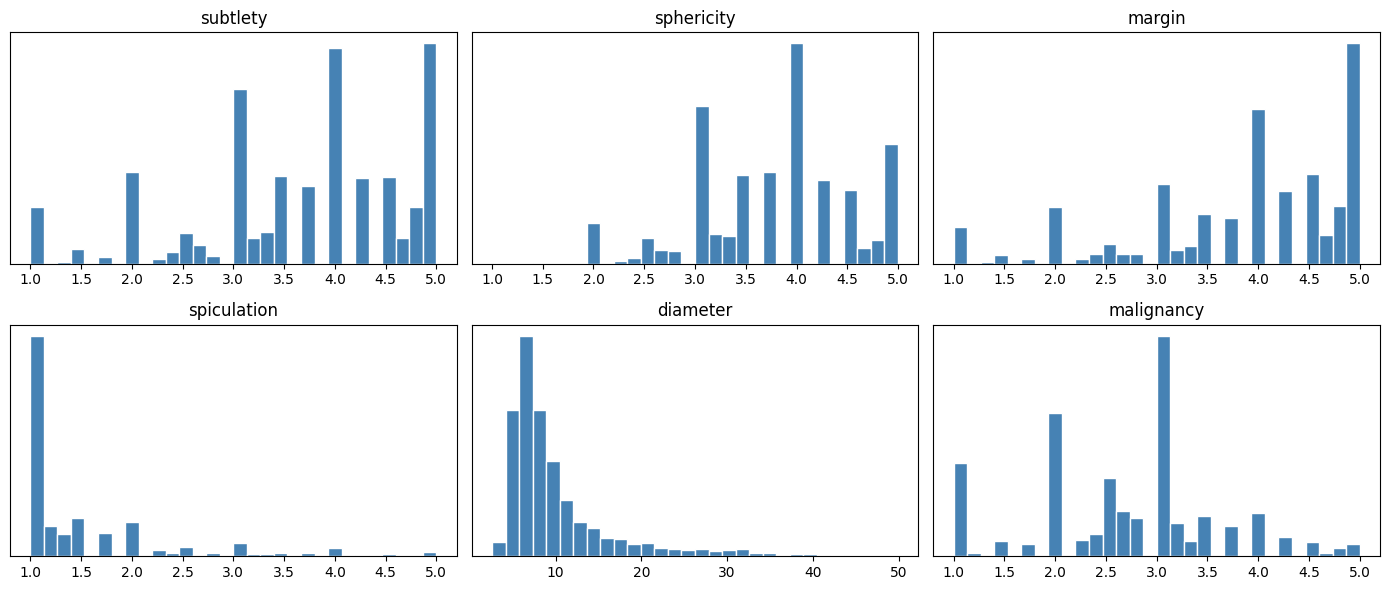

In [7]:
show = ["subtlety", "sphericity", "margin", "spiculation", "diameter", "malignancy"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, name in zip(axes.ravel(), show):
    ax.hist(df[name].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(name)
    ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Radiologist disagreement

Relevant to **Case 4**: the spread across radiologists is a free, human-derived
uncertainty estimate on the target — exactly what a distributional concept model
would try to capture.

nodules with >= 3 radiologists: 1392
mean std of their malignancy ratings: 0.640
nodules where they fully agreed    : 198 (14.2%)


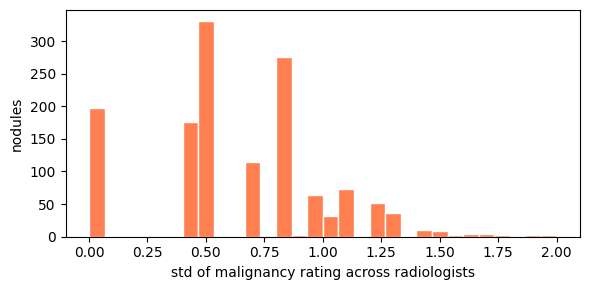

In [8]:
multi = df[df.n_annotations >= 3]
print(f"nodules with >= 3 radiologists: {len(multi)}")
print(f"mean std of their malignancy ratings: {multi.malignancy_std.mean():.3f}")
print(f"nodules where they fully agreed    : {(multi.malignancy_std == 0).sum()} "
      f"({(multi.malignancy_std == 0).mean():.1%})")

plt.figure(figsize=(6, 3))
plt.hist(multi.malignancy_std, bins=30, color="coral", edgecolor="white")
plt.xlabel("std of malignancy rating across radiologists")
plt.ylabel("nodules"); plt.tight_layout(); plt.show()

## 8. Getting the images

The concepts above needed no images. Training does.

The full collection is **128 GB** — 1018 chest CTs, ~200 slices each. We do not
want that on disk. But a nodule is only a few millimetres across, so almost all
of it is wasted. `scripts/prepare_lidc.py` handles this:

```
download one scan (~100 MB)  ->  cut a 64x64x64 mm box around each nodule
                             ->  save the boxes (512 KB each)
                             ->  delete the scan, move to the next
```

Only one scan is ever on disk. All 2651 nodules come to about **1.3 GB**.

Each box is resampled to 1 mm voxels first, so 64 always means 64 mm. Without
that, a box would cover a different physical size in every scan — slice spacing
varies from 0.6 to 5 mm — and shape concepts like sphericity would be
meaningless.

```bash
python scripts/prepare_lidc.py --n-patients 50      # ~5 GB downloaded, ~250 MB kept
python scripts/prepare_lidc.py --all                # everything, a few hours
```

It writes `data/processed/lidc/cubes/*.npy` plus a `nodules.csv` of concepts and
labels, and records finished patients in `.done` so you can stop and resume.

## 9. What the cubes look like

Three neighbouring slices through the middle of each box. The nodule is at the
centre by construction, marked with a cross.

Displayed in the usual lung window (-1000 to 400 HU): air is black, soft tissue
white.

In [ ]:
import glob
from pathlib import Path

CUBES = Path("data/processed/lidc/cubes")
meta  = Path("data/processed/lidc/nodules.csv")

if not CUBES.exists() or not list(CUBES.glob("*.npy")):
    print("No cubes yet. Run:  python scripts/prepare_lidc.py --n-patients 50")
else:
    cubes = sorted(CUBES.glob("*.npy"))
    info  = pd.read_csv(meta).set_index("file")
    rng   = np.random.default_rng(0)
    pick  = rng.choice(len(cubes), size=min(4, len(cubes)), replace=False)

    print(f"{len(cubes)} cubes on disk "
          f"({sum(f.stat().st_size for f in cubes)/1e6:.0f} MB)\n")

    fig, axes = plt.subplots(len(pick), 3, figsize=(9, 3 * len(pick)))
    axes = np.atleast_2d(axes)
    for r, i in enumerate(pick):
        cube = np.load(cubes[i])
        row  = info.loc[cubes[i].name]
        for c, z in enumerate([30, 32, 34]):                 # 3 slices around centre
            ax = axes[r, c]
            ax.imshow(np.clip(cube[:, :, z], -1000, 400), cmap="gray")
            ax.plot(32, 32, "r+", ms=12, mew=1.5)
            ax.axis("off")
            if c == 1:
                ax.set_title(
                    f"{row.name}   {cube.shape}   diameter {row.diameter:.0f} mm   "
                    f"malignancy {row.malignancy:.2f}  ->  label {int(row.label)}",
                    fontsize=9)
    plt.tight_layout(); plt.show()